TASK 5: USE-CASE STUDY

5.1

In [21]:
#pandas for data processing
import pandas as pd
#dataframe for type hinting
from pandas import DataFrame
#cast to help pycharm understand object type
from typing import cast

#load csv file
df = cast (DataFrame, pd.read_csv(
    "karakter.csv",
    #tab separated values
    sep="\t",
    #utf16-little endian encoding
    encoding="utf-16-le",
    #skips first line
    skiprows=1,
    decimal=","
))
#show first row of the dataset
print(df.head())

#show all column names
print(df.columns)


#saved file as utf-8, easier to work with and better supported
df.to_csv(
    "fixed_utf8.csv",
    sep="\t",
    encoding="utf-8",
    index=False
)
#confirmation message
print("Saved fixed_utf8.csv")

   FagNivaa  EnhetNivaa Vurderingsfagkode Nasjonaltkode  Fylkekode  \
0         2           0           ENG1007          Alle          0   
1         2           1           ENG1007             I          0   
2         2           2           ENG1007             I          3   
3         2           3           ENG1007             I          3   
4         2           3           ENG1007             I          3   

  Organisasjonsnummer                                 Vurderingsfagnavn  \
0                Alle  Engelsk vg1 studieforberedende utdanningsprogram   
1                   I  Engelsk vg1 studieforberedende utdanningsprogram   
2                  03  Engelsk vg1 studieforberedende utdanningsprogram   
3           887664102  Engelsk vg1 studieforberedende utdanningsprogram   
4           988938386  Engelsk vg1 studieforberedende utdanningsprogram   

     Nasjonalt        Fylke                 EnhetNavn  \
0  Hele landet  Alle fylker               Alle skoler   
1  Hele landet

5.2

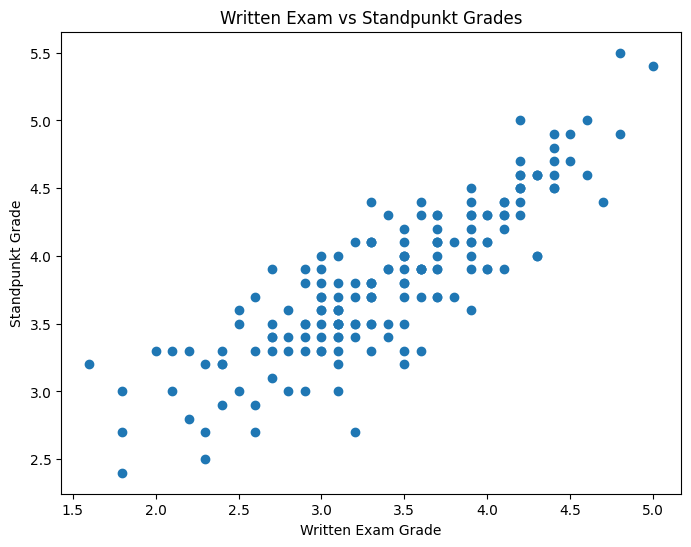

In [22]:
#pandas for data processing
import pandas as pd

#matplotlib for visualization
import matplotlib.pyplot as plt

#read the cleaned CSV file
#sep="\t" because the file is tab-separated
#encoding="utf-8" because we converted the file earlier
df = pd.read_csv(
    "fixed_utf8.csv",
    sep="\t",
    encoding="utf-8",
)

#column containing written exam average grades
written_col = "2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter"

#column containing standpunkt average grades
stand_col = "2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter"

#loop through both grade columns
for col in [written_col, stand_col]:

    #convert all values to strings first, this makes it possible to replace commas
    df[col] = (
        df[col]
        .astype(str)

        #norwegian decimals use commas (4,5), so we replace commas with dots (4.5)
        .str.replace(",", ".", regex=False)
    )

    #convert the cleaned strings into numeric values, errors="coerce" changes invalid values into NaN
    df[col] = pd.to_numeric(df[col], errors="coerce")

#remove rows where either column has missing values, this ensures only complete rows are used in the plot
filtered = df.dropna(subset=[written_col, stand_col])

#create a new figure with custom size
plt.figure(figsize=(8, 6))

#create scatter plot: x-axis = written exam grades and y-axis = standpunkt grades
#each dot represent one observation
plt.scatter(
    filtered[written_col],
    filtered[stand_col]
)

#label for x-axis
plt.xlabel("Written Exam Grade")

#label for y-axis
plt.ylabel("Standpunkt Grade")

#title of the graph
plt.title("Written Exam vs Standpunkt Grades")

#display the plot
plt.show()

Findings:
Schools with high written exam grades usually also have high standpunkt grades.
Standpunkt grades are often slightly higher than written exam grades.
The positive correlation indicates consistency between coursework performance and exam performance.

5.3

Written exam average: 3.3988505747126436
Oral exam average: 4.4452380952380945
Standpunkt average: 3.9540856031128406


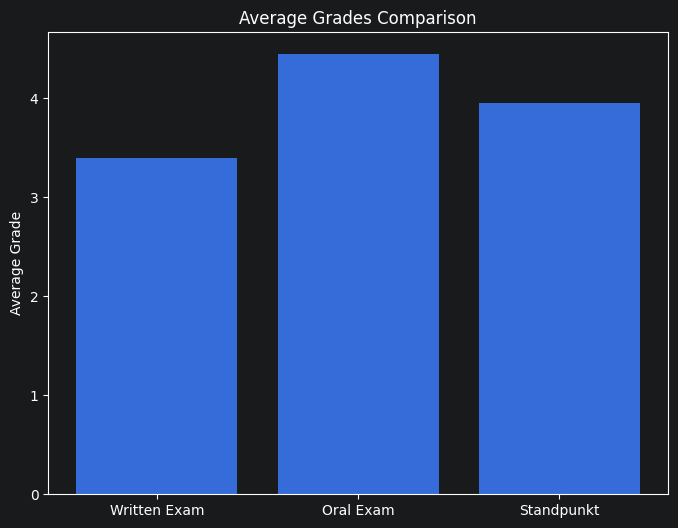

In [25]:
import pandas as pd
import matplotlib.pyplot as plt


#load the cleaned CSV file
df = pd.read_csv(
    "fixed_utf8.csv",
    sep="\t",
    encoding="utf-8"
)


#column names

written_col = "2024-25.Skriftlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter"

oral_col = "2024-25.Muntlig eksamen.Alle eierformer.Alle kjønn.Snittkarakter"

stand_col = "2024-25.Standpunkt.Alle eierformer.Alle kjønn.Snittkarakter"


#convert Norwegian decimals. Example: "4,5" -> "4.5"
for col in [written_col, oral_col, stand_col]:

    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace("*", "", regex=False)
    )

    #convert text to numbers
    df[col] = pd.to_numeric(df[col], errors="coerce")


#calculate average grades
written_avg = df[written_col].mean()
oral_avg = df[oral_col].mean()
stand_avg = df[stand_col].mean()

#print averages

print("Written exam average:", written_avg)
print("Oral exam average:", oral_avg)
print("Standpunkt average:", stand_avg)


#create bar chart

labels = [
    "Written Exam",
    "Oral Exam",
    "Standpunkt"
]

averages = [
    written_avg,
    oral_avg,
    stand_avg
]

#create figure size
plt.figure(figsize=(8, 6))

#create bars
plt.bar(labels, averages)

#labels and title
plt.ylabel("Average Grade")

plt.title("Average Grades Comparison")

#show chart
plt.show()

This vizualization shows that written exams are generally than standpunkt grades, while oral grades generally are higher than standpunkt. This supports the claim in the article (link?) that students tend to perform "best" in oral exams and receive higher standpunkt grades than in written exams.